In [2]:
from utils.dataset import dataset_prep
from omegaconf import OmegaConf

MAX_SAMPLES = 10
dataset_cfg = OmegaConf.load("configs/dataset.yaml")
dataset_cfg.dataset.max_samples = MAX_SAMPLES # Overwrite max_samples for quick experimentation
ds = dataset_prep(dataset_cfg.dataset)
ds_train = ds["train"]

[12:31:44] Detected 1-based labels (min=1, max=4); converting to 0-based before cast
Map: 216000 examples [00:02, 43291.03 examples/s]          
Map: 24000 examples [00:00, 29247.83 examples/s]         
Map: 15200 examples [00:00, 76948.00 examples/s]       
[12:31:48] Subsampling the training set to 10 examples for faster experimentation.
[12:31:50] Loaded dataset sh0416/ag_news with splits: dict_keys(['train', 'dev', 'test'])
[12:31:50] Preprocessing splits...
Map: 100%|██████████| 10/10 [00:00<00:00, 3127.98 examples/s]
Map: 24000 examples [00:00, 44966.92 examples/s]         
Map: 15200 examples [00:00, 44804.39 examples/s]       
[12:31:51] Dataset preprocessing complete. Sample from preprocessed dataset: {'labels': 3, 'title': '-Posted by dan.farber  7:24 pm (PDT)', 'description': 'One day Hewlett-Packards Utility Data Center (UDC) is proof of the companys leadership in the emerging on demand, adaptive computing, pay-as-you-go world.', 'text': 'Title: -Posted by dan.farber 7:24 p

In [3]:
ds_train[0]

{'labels': 3,
 'title': "Sun's Linux wins right to be considered in Japan",
 'description': "They're on a list, and they want to tell us all about it",
 'text': "Sun's Linux wins right to be considered in Japan They're on a list, and they want to tell us all about it"}

In [4]:
# frequency distribution of labels
from collections import Counter

label_counts = Counter(ds_train["labels"])
print(label_counts)

Counter({3: 256, 2: 251, 1: 248, 0: 245})


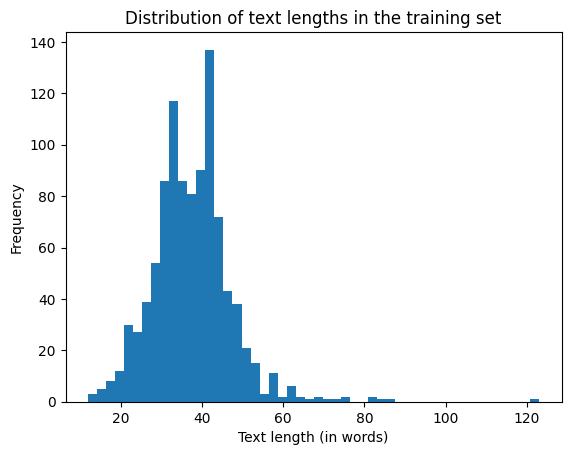

In [5]:
# Length of the texts
text_lengths = [len(text.split()) for text in ds_train["text"]]
import matplotlib.pyplot as plt
plt.hist(text_lengths, bins=50)
plt.xlabel("Text length (in words)")
plt.ylabel("Frequency")
plt.title("Distribution of text lengths in the training set")
plt.show()

[21:42:23] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[21:42:23] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


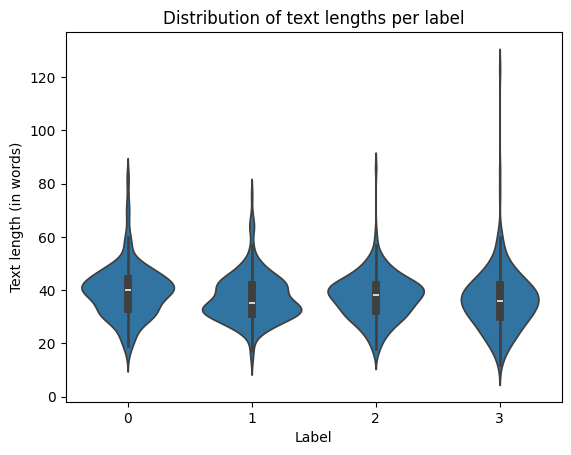

In [11]:
# distribution of labels per text length (violin plot)
import seaborn as sns
import pandas as pd
df = pd.DataFrame({"text_length": text_lengths, "label": ds_train["labels"]})
sns.violinplot(x="label", y="text_length", data=df)
plt.xlabel("Label")
plt.ylabel("Text length (in words)")
plt.title("Distribution of text lengths per label")
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sigurdurhaukur/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


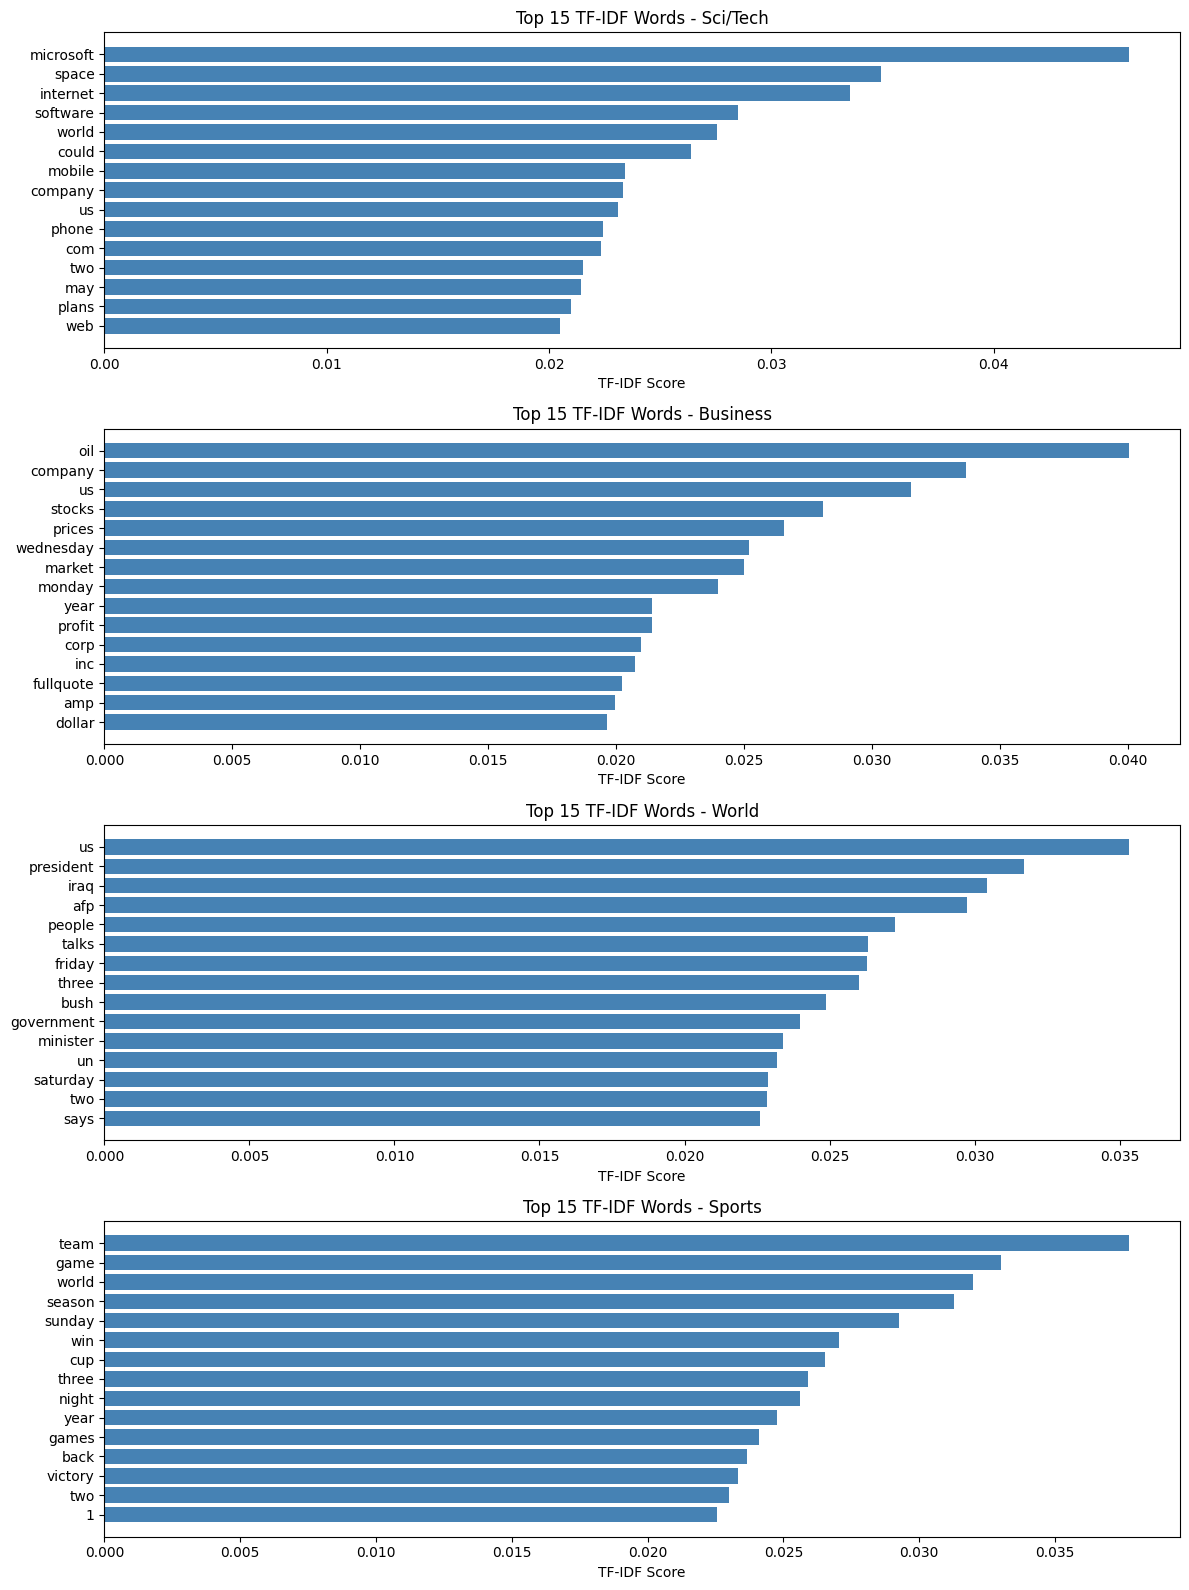

In [6]:
from collections import defaultdict, Counter
import nltk
from nltk.corpus import stopwords
import re
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Add domain-specific stopwords
domain_stops = {"said", "new", "ap", "reuters", "quot", "one", "u", "n", "first"} # Words that "poisoned" the previous analysis
custom_stops = stop_words | domain_stops

# Prepare texts grouped by label
texts_by_label = defaultdict(list)
for text, label in zip(ds_train["text"], ds_train["labels"]):
    texts_by_label[label].append(text)

# Compute TF-IDF for each label
tfidf_scores = {}
for label, texts in texts_by_label.items():
    vectorizer = TfidfVectorizer(
        stop_words=list(custom_stops),
        token_pattern=r"\b\w+\b", # Keep only words (no punctuation)
        lowercase=True,
        max_features=5000,
        min_df=5, # Ignore words that appear in less than 5 documents
        max_df=0.8, # Ignore words that appear in more than 80% of documents
        ngram_range=(1, 2)
    )
    tfidf_matrix = vectorizer.fit_transform(texts)
    # Average TF-IDF scores across documents
    avg_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    vocab = vectorizer.get_feature_names_out()
    tfidf_scores[label] = list(zip(vocab, avg_tfidf))
    tfidf_scores[label].sort(key=lambda x: x[1], reverse=True)

# Plot distribution
num_labels = len(tfidf_scores)
fig, axes = plt.subplots(num_labels, 1, figsize=(12, 4 * num_labels))
if num_labels == 1:
    axes = [axes]

for idx, (label, scores) in enumerate(tfidf_scores.items()):
    label_str = dataset_cfg.dataset.label_mapping[label + 1]
    top_words = scores[:15]
    words, tfidf_vals = zip(*top_words)
    axes[idx].barh(words, tfidf_vals, color="steelblue")
    axes[idx].set_xlabel("TF-IDF Score")
    axes[idx].set_title(f"Top 15 TF-IDF Words - {label_str}")
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()


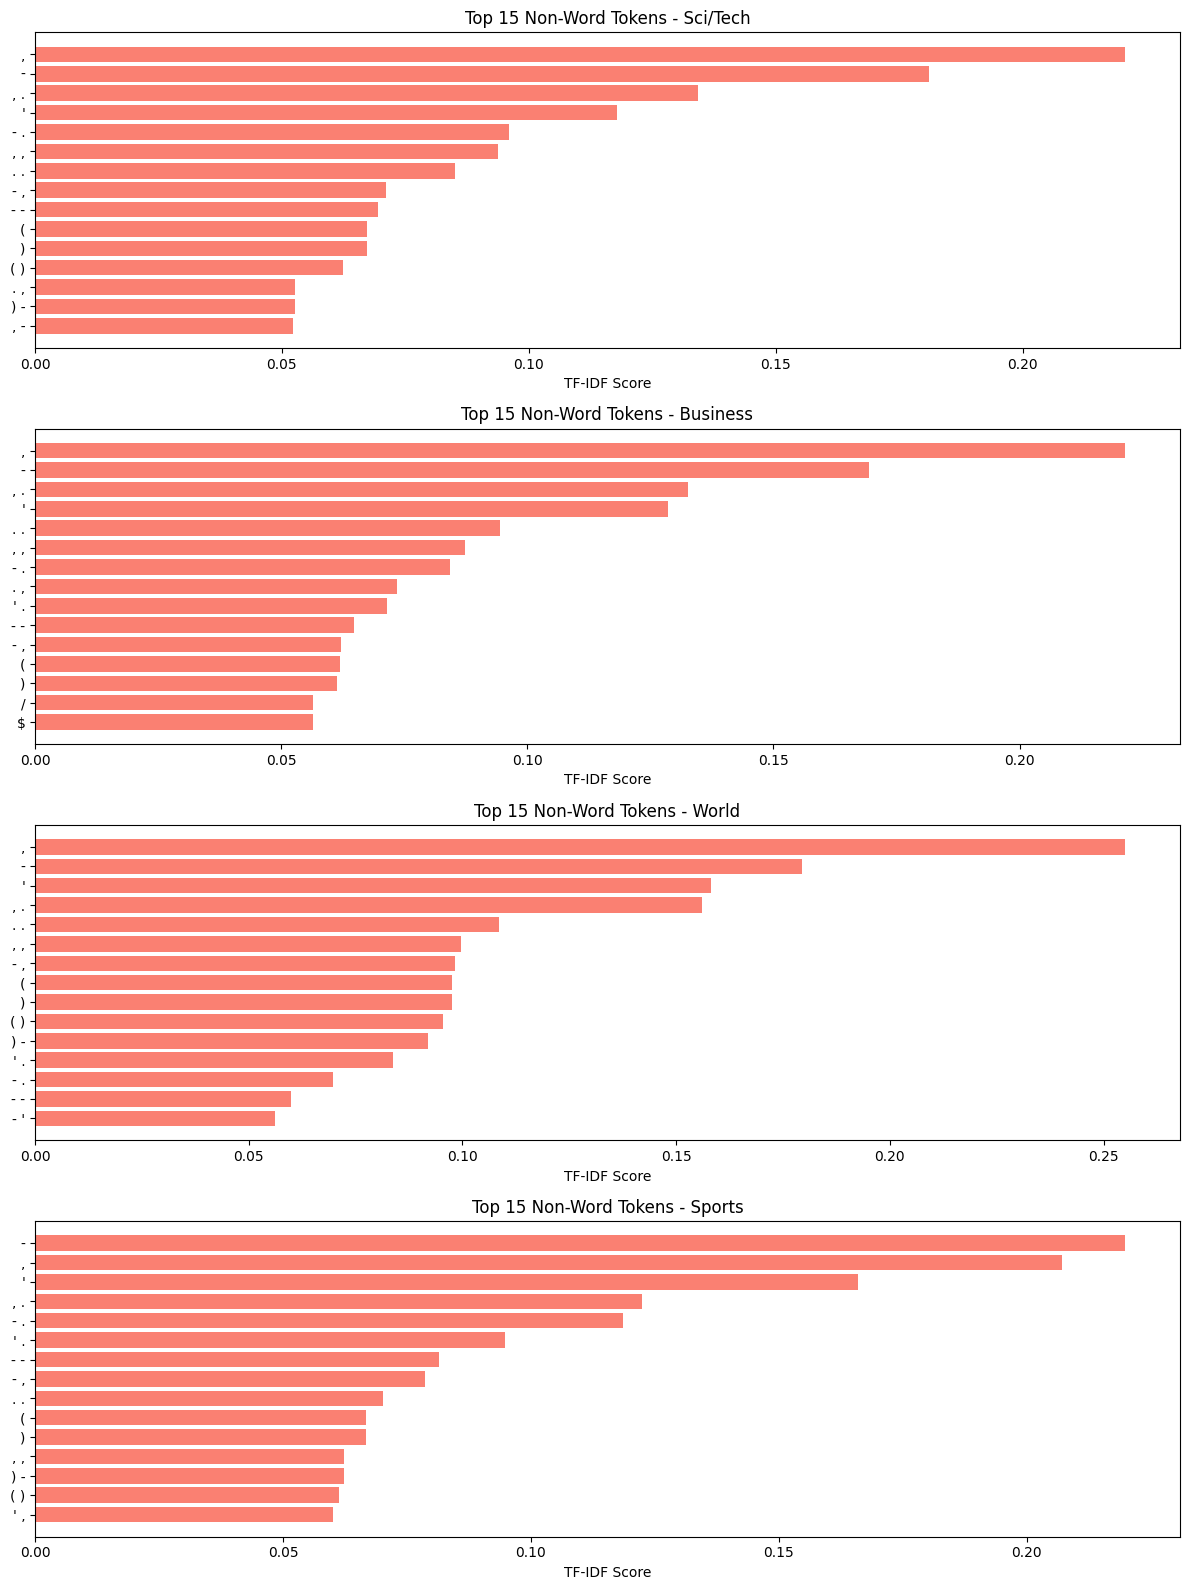

In [14]:
# TF-IDF on non-words. Just for fun, to see if there are any patterns in the punctuation or special characters. We can also use this to identify any "poisonous" tokens that might be leaking information about the labels.

# Don't count regular punctuation

tfidf_scores_non_words = {}
for label, texts in texts_by_label.items():
    texts = [re.sub(r"\w+", "", text) for text in texts] # Remove words, keep only non-word tokens
    texts = [text for text in texts if text.strip()] # Remove empty texts
    vectorizer = TfidfVectorizer(
        stop_words=list(custom_stops),
        token_pattern=r"\S", # Keep only non-whitespace characters
        lowercase=False,
        max_features=100,
        min_df=5,
        max_df=0.8,
        ngram_range=(1, 2)

    )
    tfidf_matrix = vectorizer.fit_transform(texts)
    avg_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    vocab = vectorizer.get_feature_names_out()
    tfidf_scores_non_words[label] = list(zip(vocab, avg_tfidf))
    tfidf_scores_non_words[label].sort(key=lambda x: x[1], reverse=True)

# Plot distribution of non-word tokens
num_labels = len(tfidf_scores_non_words)
fig, axes = plt.subplots(num_labels, 1, figsize=(12, 4 * num_labels))
if num_labels == 1:
    axes = [axes]
for idx, (label, scores) in enumerate(tfidf_scores_non_words.items()):
    label_str = dataset_cfg.dataset.label_mapping[label + 1]
    top_tokens = scores[:15]
    tokens, tfidf_vals = zip(*top_tokens)
    axes[idx].barh(tokens, tfidf_vals, color="salmon")
    axes[idx].set_xlabel("TF-IDF Score")
    axes[idx].set_title(f"Top 15 Non-Word Tokens - {label_str}")
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

In [7]:
# Save TF-IDF scores per label to a file
import json

tfidf_output = {}
for label, scores in tfidf_scores.items():
    label_str = dataset_cfg.dataset.label_mapping[label + 1]
    tfidf_output[label_str] = [{"word": word, "score": score} for word, score in scores]

with open("tfidf_scores_by_label.json", "w") as f:
    json.dump(tfidf_output, f, indent=4)

In [8]:
# Load and print TF-IDF scores from file
with open("tfidf_scores_by_label.json", "r") as f:
    loaded_tfidf = json.load(f)

for label, word_scores in loaded_tfidf.items():
    print(f"Label: {label}")
    for entry in word_scores[:3]:  # Print top 3 words
        print(f"  Word: {entry['word']}, Score: {entry['score']:.4f}")
    print()

Label: Sci/Tech
  Word: microsoft, Score: 0.0461
  Word: space, Score: 0.0349
  Word: internet, Score: 0.0336

Label: Business
  Word: oil, Score: 0.0400
  Word: company, Score: 0.0337
  Word: us, Score: 0.0315

Label: World
  Word: us, Score: 0.0353
  Word: president, Score: 0.0317
  Word: iraq, Score: 0.0304

Label: Sports
  Word: team, Score: 0.0377
  Word: game, Score: 0.0330
  Word: world, Score: 0.0320



In [9]:
# Masking out top TF-IDF words from the test set and saving the modified dataset for later evaluation (keyword masking probing)
# --- mask_and_save.py ---
from transformers import AutoTokenizer
import re

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
vocab = tokenizer.get_vocab()
mask_token = tokenizer.mask_token if tokenizer.mask_token is not None else tokenizer.unk_token
max_len = tokenizer.model_max_length if tokenizer.model_max_length and tokenizer.model_max_length < 10000 else 512

ds_test = ds["test"]

TOP_N = 20
top_words = [word for word, _ in tfidf_scores[0][:TOP_N]]
pattern = re.compile(
    r"\b(" + "|".join(re.escape(w) for w in top_words) + r")\b", flags=re.IGNORECASE
)


def mask_text(example):
    masked = pattern.sub(mask_token, example["text"])
    return {"text": masked}


# Re-tokenize after masking so input_ids reflect the masked text
def tokenize(example):
    encoded = tokenizer(
        example["text"],
        add_special_tokens=False,
        truncation=True,
        max_length=max_len,
    )
    input_ids = encoded["input_ids"]
    input_ids = input_ids[:max_len] + [tokenizer.pad_token_id or 0] * max(0, max_len - len(input_ids))
    return {"input_ids": input_ids}


masked_ds = ds_test.map(mask_text)
masked_ds = masked_ds.map(tokenize)
masked_ds.save_to_disk("masked_test_set")

Saving the dataset (1/1 shards): 100%|██████████| 1000/1000 [00:00<00:00, 222485.89 examples/s]


In [3]:
# what is the token per word ratio on the preprocessed training set?

from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")
model = AutoModelForMaskedLM.from_pretrained("distilbert/distilbert-base-uncased")

token_counts = [len(tokenizer.tokenize(text)) for text in ds_train["text"]]
word_counts = [len(text.split()) for text in ds_train["text"]]
token_per_word_ratios = [t / w if w > 0 else 0 for t, w in zip(token_counts, word_counts)]
average_ratio = sum(token_per_word_ratios) / len(token_per_word_ratios)
print(f"Average token per word ratio: {average_ratio:.2f}")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 13071.02it/s]

Average token per word ratio: 1.41
